# Employee Performance Visualization

This notebook presents the key findings from the Employee Performance Analysis project through focused visualizations.

The visualizations are based on the processed employee performance dataset and the results obtained during exploratory analysis and model development.

The main objectives are to visually communicate:

1. Department-wise employee performance
2. The most important factors associated with performance
3. Comparison of classification models
4. Performance of the final selected model
5. Key analytical insights relevant to employee performance

In [1]:
# ============================================================
# 4.1 Import Libraries and Load Processed Dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Load processed dataset
processed_path = "../../data/processed/employee_performance_processed.csv"

df = pd.read_csv(processed_path)

print("=" * 80)
print("VISUALIZATION NOTEBOOK - DATA LOADED")
print("=" * 80)

print(f"\nDataset shape: {df.shape}")
print(f"Number of employees: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

VISUALIZATION NOTEBOOK - DATA LOADED

Dataset shape: (1200, 27)
Number of employees: 1200
Number of columns: 27


## 4.2 Overall Performance Rating Distribution

The distribution of `PerformanceRating` is visualized to show the proportion of employees in each performance category.

The dataset contains three observed performance ratings: 2, 3, and 4.

The distribution is imbalanced, with Rating 3 representing the majority of employees.

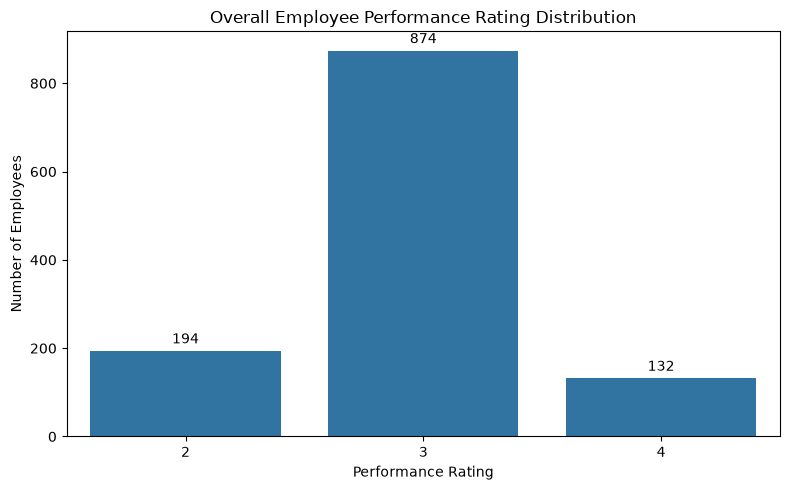

In [2]:
# ============================================================
# 4.2 Overall Performance Rating Distribution
# ============================================================

rating_counts = (
    df["PerformanceRating"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=rating_counts.index.astype(str),
    y=rating_counts.values
)

plt.title("Overall Employee Performance Rating Distribution")
plt.xlabel("Performance Rating")
plt.ylabel("Number of Employees")

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

## 4.2 Department-wise Performance

This visualization compares the distribution of PerformanceRating across departments.

The percentages are calculated within each department so that the performance composition of departments can be compared fairly, regardless of differences in department size.

<Figure size 1000x600 with 0 Axes>

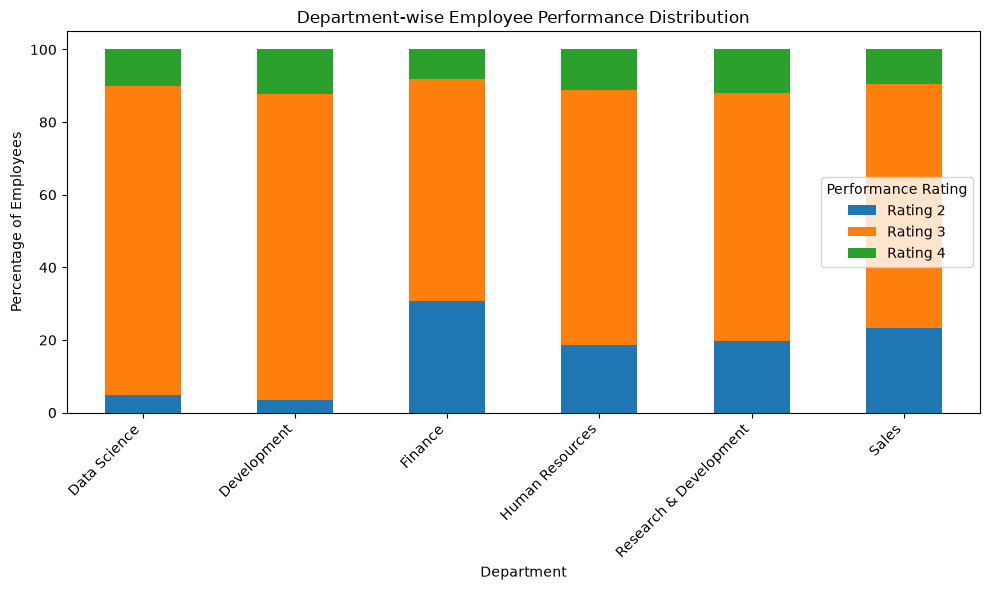

In [3]:
# ============================================================
# 4.2 Department-wise Performance
# ============================================================

department_performance = pd.crosstab(
    df["EmpDepartment"],
    df["PerformanceRating"],
    normalize="index"
) * 100

# Ensure all observed rating columns are present and ordered
department_performance = department_performance.reindex(
    columns=[2, 3, 4],
    fill_value=0
)

department_performance.columns = [
    "Rating 2",
    "Rating 3",
    "Rating 4"
]

plt.figure(figsize=(10, 6))

ax = department_performance.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Department-wise Employee Performance Distribution")
plt.xlabel("Department")
plt.ylabel("Percentage of Employees")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Performance Rating")

plt.tight_layout()
plt.show()

## 4.3 Top 3 Important Factors Affecting Employee Performance

The tuned XGBoost model identified the three most important original employee attributes based on aggregated feature importance.

The top three factors are:

1. EmpJobRole
2. EmpEnvironmentSatisfaction
3. EmpDepartment

Feature importance represents the contribution of these variables to the model's predictive decisions. It indicates predictive association and should not be interpreted as proof of causation.

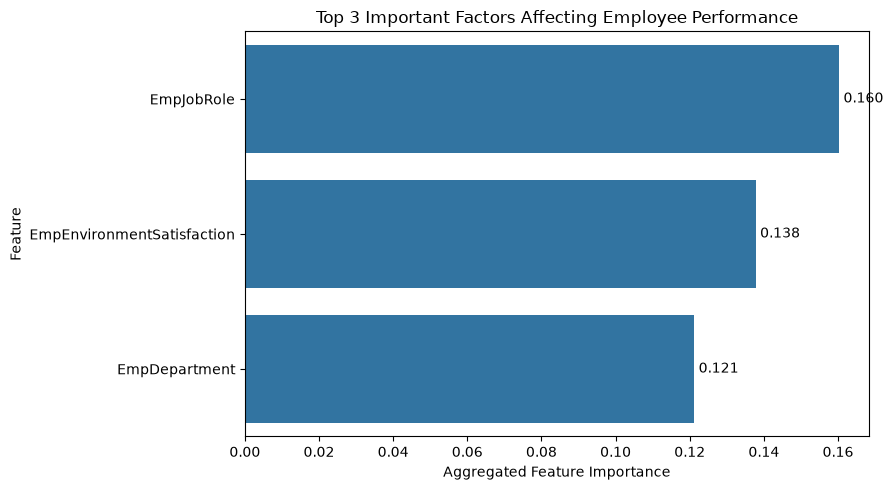

In [4]:
# ============================================================
# 4.3 Top 3 Important Factors
# ============================================================

top_3_features = pd.DataFrame({
    "Feature": [
        "EmpJobRole",
        "EmpEnvironmentSatisfaction",
        "EmpDepartment"
    ],
    "Importance": [
        0.160347,
        0.137851,
        0.121276
    ]
})

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=top_3_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 3 Important Factors Affecting Employee Performance")
plt.xlabel("Aggregated Feature Importance")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

## 4.4 Model Comparison

The classification models evaluated during model development are compared using 5-fold stratified cross-validation Macro F1 score.

Macro F1 is used because the PerformanceRating classes are imbalanced. It gives equal importance to each performance-rating class rather than allowing the majority class to dominate the metric.

The comparison helps illustrate the relative predictive performance of the evaluated models before hyperparameter tuning.

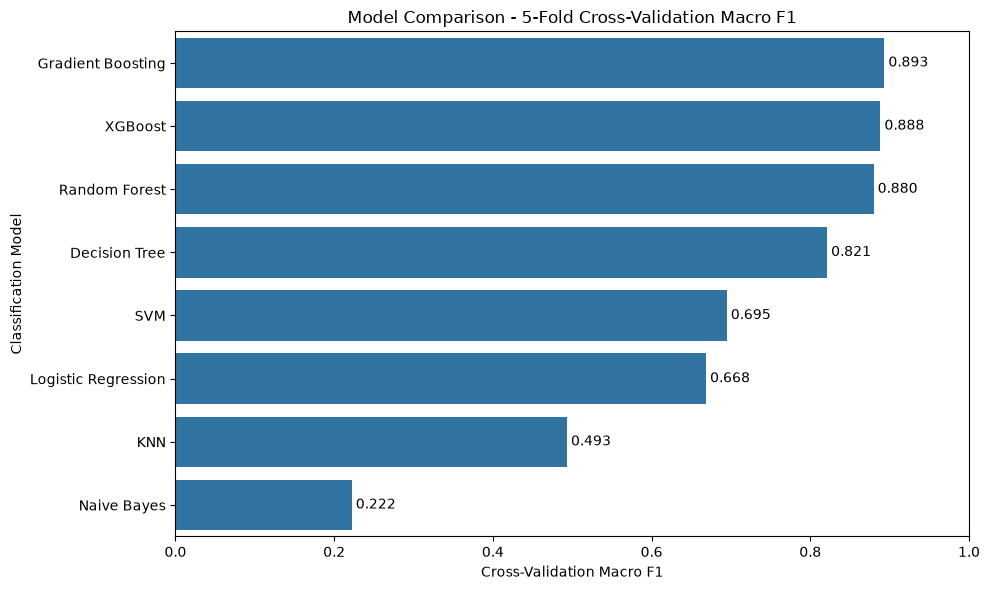

In [5]:
# ============================================================
# 4.4 Model Comparison - Cross-Validation Macro F1
# ============================================================

model_cv_results = pd.DataFrame({
    "Model": [
        "Gradient Boosting",
        "XGBoost",
        "Random Forest",
        "Decision Tree",
        "SVM",
        "Logistic Regression",
        "KNN",
        "Naive Bayes"
    ],
    "CV Macro F1": [
        0.893170,
        0.888196,
        0.879675,
        0.820989,
        0.694628,
        0.668450,
        0.493180,
        0.222046
    ]
})

model_cv_results = model_cv_results.sort_values(
    "CV Macro F1",
    ascending=False
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=model_cv_results,
    x="CV Macro F1",
    y="Model"
)

plt.title("Model Comparison - 5-Fold Cross-Validation Macro F1")
plt.xlabel("Cross-Validation Macro F1")
plt.ylabel("Classification Model")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 4.5 Final Tuned Model Performance

The three models selected for hyperparameter tuning were evaluated on the test dataset after tuning.

Macro F1 is used as the primary comparison metric because the target classes are imbalanced.

The tuned XGBoost model achieved a Macro F1 of 0.9003 on the test set and a best cross-validation Macro F1 of 0.9041.

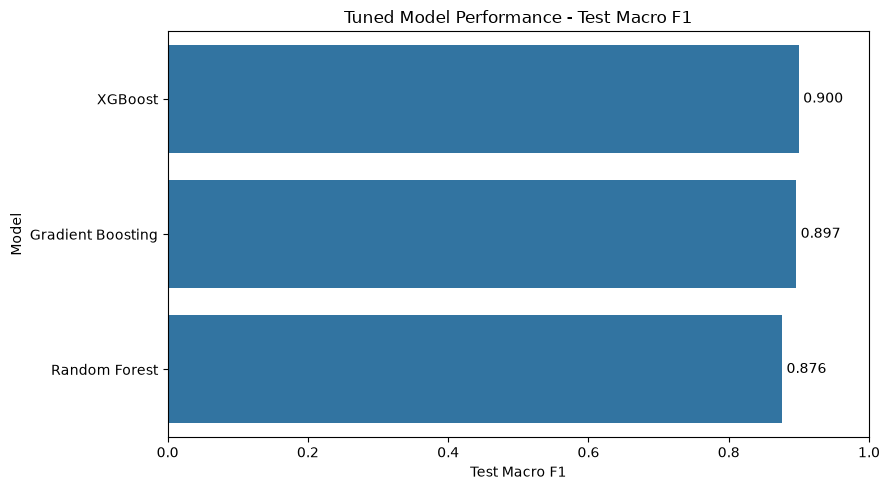

In [6]:
# ============================================================
# 4.5 Final Tuned Model Performance
# ============================================================

tuned_model_results = pd.DataFrame({
    "Model": [
        "XGBoost",
        "Gradient Boosting",
        "Random Forest"
    ],
    "Macro F1": [
        0.900253,
        0.896630,
        0.876438
    ]
})

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=tuned_model_results,
    x="Macro F1",
    y="Model"
)

plt.title("Tuned Model Performance - Test Macro F1")
plt.xlabel("Test Macro F1")
plt.ylabel("Model")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 4.6 Final XGBoost Model - Class-wise Performance

The classification performance of the final tuned XGBoost model is examined separately for each PerformanceRating class.

Precision, recall, and F1-score are presented for Ratings 2, 3, and 4.

This provides a more detailed view of how the final model performs across the different performance categories.

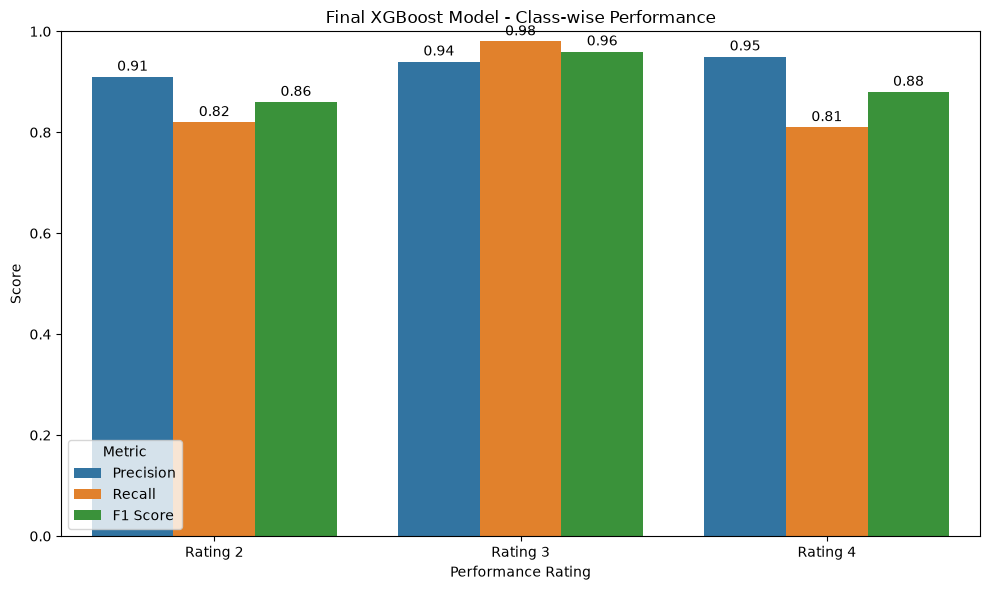

In [7]:
# ============================================================
# 4.6 Final XGBoost Model - Class-wise Performance
# ============================================================

class_performance = pd.DataFrame({
    "Performance Rating": ["Rating 2", "Rating 3", "Rating 4"],
    "Precision": [0.91, 0.94, 0.95],
    "Recall": [0.82, 0.98, 0.81],
    "F1 Score": [0.86, 0.96, 0.88]
})

class_performance_long = class_performance.melt(
    id_vars="Performance Rating",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=class_performance_long,
    x="Performance Rating",
    y="Score",
    hue="Metric"
)

plt.title("Final XGBoost Model - Class-wise Performance")
plt.xlabel("Performance Rating")
plt.ylabel("Score")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2)

plt.tight_layout()
plt.show()

## 4.7 Top 10 Feature Importances

The top 10 original employee attributes based on the tuned XGBoost feature importance are visualized.

Categorical variables were one-hot encoded during preprocessing, so their importance values were aggregated back to their original feature names.

The resulting visualization provides an overall view of the variables that contributed most to the model's predictive decisions.

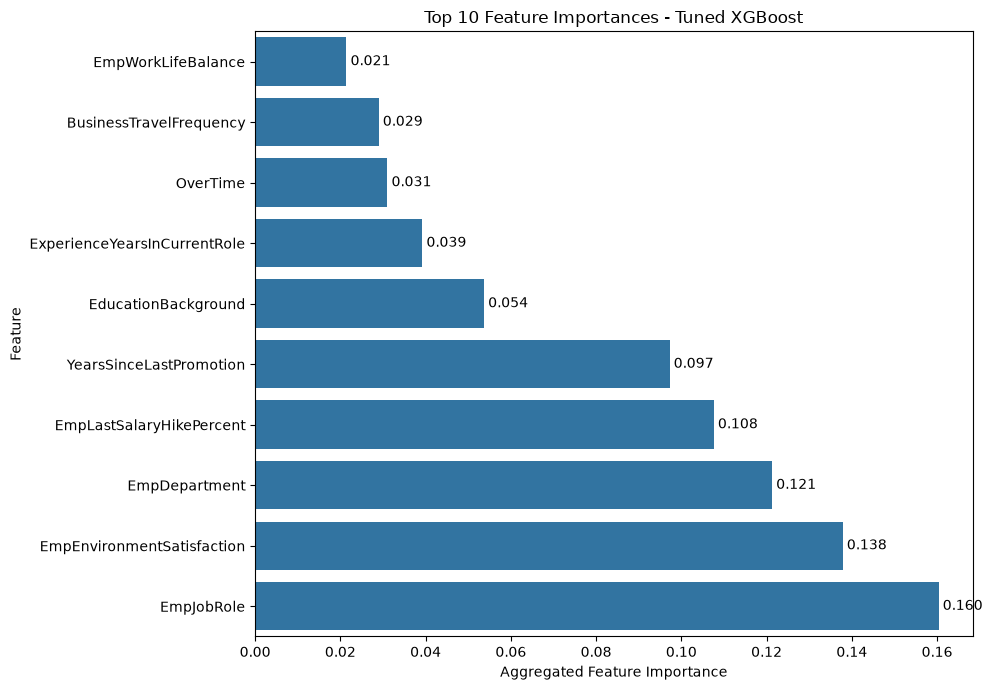

In [8]:
# ============================================================
# 4.7 Top 10 Feature Importances
# ============================================================

top_10_feature_importance = pd.DataFrame({
    "Feature": [
        "EmpJobRole",
        "EmpEnvironmentSatisfaction",
        "EmpDepartment",
        "EmpLastSalaryHikePercent",
        "YearsSinceLastPromotion",
        "EducationBackground",
        "ExperienceYearsInCurrentRole",
        "OverTime",
        "BusinessTravelFrequency",
        "EmpWorkLifeBalance"
    ],
    "Importance": [
        0.160347,
        0.137851,
        0.121276,
        0.107597,
        0.097228,
        0.053696,
        0.039213,
        0.031020,
        0.028977,
        0.021407
    ]
})

top_10_feature_importance = top_10_feature_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=top_10_feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - Tuned XGBoost")
plt.xlabel("Aggregated Feature Importance")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

## 4.8 Environment Satisfaction and Employee Performance

Employee Environment Satisfaction was identified as the second most important feature by the tuned XGBoost model.

The visualization shows the distribution of PerformanceRating within each environment satisfaction level.

This helps illustrate the observed relationship between workplace environment satisfaction and employee performance in the dataset.

<Figure size 900x600 with 0 Axes>

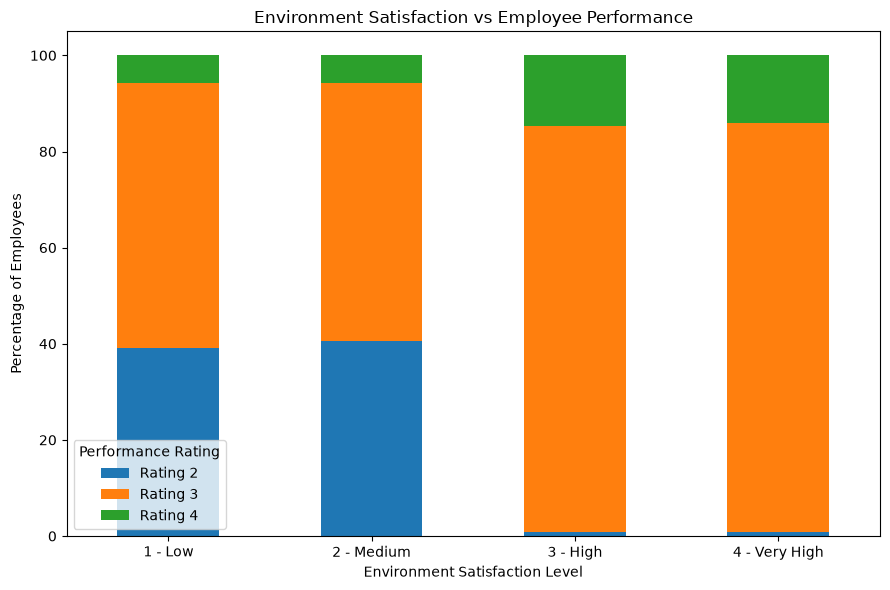

In [9]:
# ============================================================
# 4.8 Environment Satisfaction and Employee Performance
# ============================================================

environment_performance = pd.crosstab(
    df["EmpEnvironmentSatisfaction"],
    df["PerformanceRating"],
    normalize="index"
) * 100

environment_performance = environment_performance.reindex(
    columns=[2, 3, 4],
    fill_value=0
)

environment_performance.columns = [
    "Rating 2",
    "Rating 3",
    "Rating 4"
]

plt.figure(figsize=(9, 6))

ax = environment_performance.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.title("Environment Satisfaction vs Employee Performance")
plt.xlabel("Environment Satisfaction Level")
plt.ylabel("Percentage of Employees")
plt.xticks(
    ticks=range(4),
    labels=[
        "1 - Low",
        "2 - Medium",
        "3 - High",
        "4 - Very High"
    ],
    rotation=0
)
plt.legend(title="Performance Rating")

plt.tight_layout()
plt.show()

## 4.9 Salary Hike and Employee Performance

`EmpLastSalaryHikePercent` was identified as an important predictive feature by the tuned XGBoost model.

The visualization compares the average salary hike percentage across the observed PerformanceRating categories.

This provides a simple view of the relationship between recent salary hikes and employee performance in the dataset.

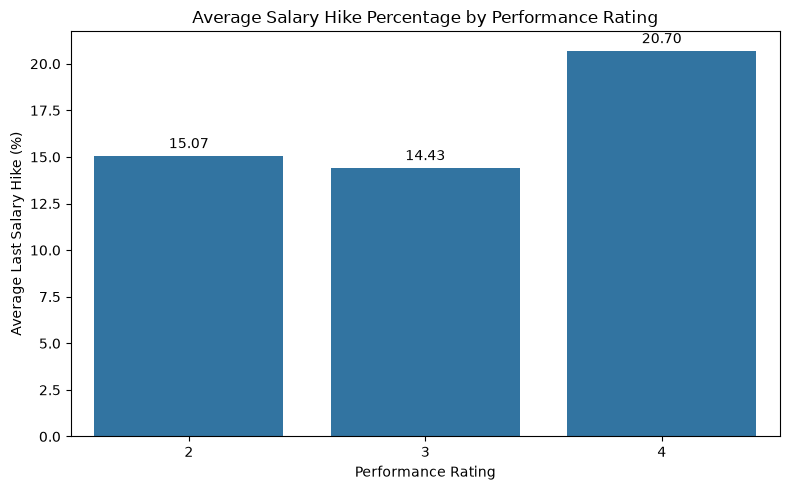

In [10]:
# ============================================================
# 4.9 Salary Hike and Employee Performance
# ============================================================

salary_hike_by_rating = (
    df.groupby("PerformanceRating")["EmpLastSalaryHikePercent"]
    .mean()
    .reindex([2, 3, 4])
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=salary_hike_by_rating.index.astype(str),
    y=salary_hike_by_rating.values
)

plt.title("Average Salary Hike Percentage by Performance Rating")
plt.xlabel("Performance Rating")
plt.ylabel("Average Last Salary Hike (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

## 4.10 Final Model Performance Summary

The final tuned XGBoost model is evaluated using multiple test-set metrics.

The metrics provide a broader view of model performance, including overall accuracy and class-balanced measures.

The final model achieved:

- Accuracy: 93.75%
- Balanced Accuracy: 87.04%
- Macro Precision: 93.62%
- Macro Recall: 87.04%
- Macro F1: 90.03%

The model also achieved a best 5-fold cross-validation Macro F1 of 90.41% during hyperparameter tuning.

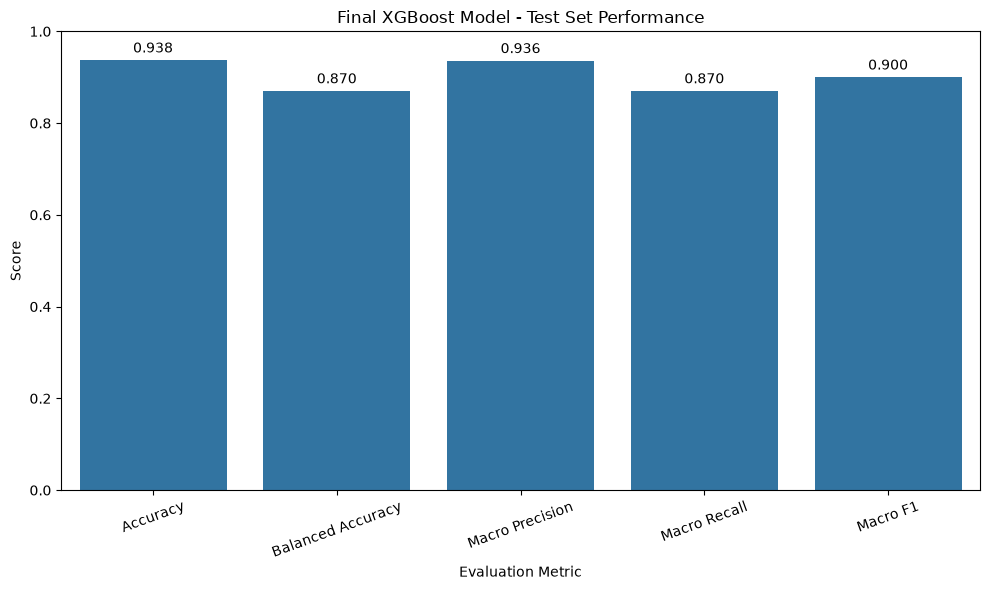

In [11]:
# ============================================================
# 4.10 Final Model Performance Summary
# ============================================================

final_model_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Score": [
        0.9375,
        0.8704,
        0.9362,
        0.8704,
        0.9003
    ]
})

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=final_model_metrics,
    x="Metric",
    y="Score"
)

plt.title("Final XGBoost Model - Test Set Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

## 4.11 Key Visualization Findings

The visual analysis provides the following key findings:

1. **Department-wise performance:** Performance Rating 3 is the dominant category across all departments, while the proportion of Rating 2 varies considerably between departments.

2. **Top predictive factors:** The tuned XGBoost model identified `EmpJobRole`, `EmpEnvironmentSatisfaction`, and `EmpDepartment` as the three most important features.

3. **Environment satisfaction:** Employees with lower environment satisfaction levels show a substantially higher proportion of Rating 2, while higher satisfaction levels are associated with a greater proportion of Ratings 3 and 4.

4. **Salary hike:** Average `EmpLastSalaryHikePercent` differs across performance-rating categories, with higher-performing employees showing higher average recent salary hikes in this dataset.

5. **Model performance:** The tuned XGBoost model achieved 93.75% test accuracy and 90.03% Macro F1, with a tuned 5-fold cross-validation Macro F1 of 90.41%.

6. **Class-wise performance:** The final model performs strongly across all three observed performance-rating classes, although class-level recall is not identical.

These findings are descriptive and model-based associations. They should not be interpreted as evidence that the identified factors directly cause employee performance.